# Head vs Travel Comparison (All-Spike, all shared cells, paired MRL)

This notebook compares `head_all_spike` vs `travel_all_spike` using the pipeline-defined all-spike `real_mrl` values saved in each run's `egocentric_tuning_summary.csv`.

Analysis rules:
- use `miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full`
- compare only shared cells matched by `category + animal_id + cell_idx`
- keep all shared cells matched by `category + animal_id + cell_idx`
- do **not** recompute MRL from raw data; use upstream pipeline `real_mrl`
- output one paired-MRL SVG figure and one stats CSV


In [1]:
from pathlib import Path
import subprocess
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from IPython.display import display


In [2]:
BASE_DIR = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4')
ROOT = BASE_DIR / 'data' / 'egocentric_tuning_carpenter_full'
NOTEBOOKS_HPC = BASE_DIR / 'notebooks_HPC'
STATS_SCRIPT = NOTEBOOKS_HPC / 'run_egocentric_summary_stats.py'

HEAD_RUN = ROOT / 'head_all_spike'
TRAVEL_RUN = ROOT / 'travel_all_spike'
HEAD_CSV = HEAD_RUN / 'egocentric_tuning_summary.csv'
TRAVEL_CSV = TRAVEL_RUN / 'egocentric_tuning_summary.csv'

OUT_DIR = ROOT / 'comparison_head_vs_travel_all_spike'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG = OUT_DIR / 'head_vs_travel_all_spike_allcells_paired_real_mrl.svg'
OUT_STATS = OUT_DIR / 'head_vs_travel_all_spike_allcells_paired_real_mrl_stats.csv'

CATEGORY_ORDER = ['CSplus', 'CSminus', 'all-nonPLC']
CATEGORY_LABEL = {'CSplus': 'CS+', 'CSminus': 'CS-', 'all-nonPLC': 'nonPLC'}
HEAD_COLOR = '#7B2D8E'
TRAVEL_COLOR = '#EE9B00'

print('ROOT:', ROOT)
print('HEAD_RUN:', HEAD_RUN)
print('TRAVEL_RUN:', TRAVEL_RUN)
print('OUT_FIG:', OUT_FIG)
print('OUT_STATS:', OUT_STATS)


ROOT: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full
HEAD_RUN: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/head_all_spike
TRAVEL_RUN: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/travel_all_spike
OUT_FIG: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/comparison_head_vs_travel_all_spike/head_vs_travel_all_spike_allcells_paired_real_mrl.svg
OUT_STATS: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/comparison_head_vs_travel_all_spike/head_vs_travel_all_spike_allcells_paired_real_mrl_stats.csv


In [3]:
CANDIDATES = [
    Path(sys.executable),
    Path('/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/bin/python'),
    Path('/opt/homebrew/Caskroom/miniforge/base/envs/adamlab_pipeline/bin/python'),
]

def has_modules(py):
    if not py.exists() or not os.access(py, os.X_OK):
        return False
    code = 'import numpy,pandas,matplotlib,scipy;print("ok")'
    res = subprocess.run([str(py), '-c', code], capture_output=True, text=True)
    return res.returncode == 0

PYTHON_EXEC = None
for candidate in CANDIDATES:
    if has_modules(candidate):
        PYTHON_EXEC = str(candidate)
        break
if PYTHON_EXEC is None:
    raise RuntimeError('No suitable Python interpreter with required packages found.')

print('Summary Python:', PYTHON_EXEC)

def ensure_summary_csv(run_dir: Path):
    summary_csv = run_dir / 'egocentric_tuning_summary.csv'
    if summary_csv.exists():
        print('Summary already exists:', summary_csv)
        return summary_csv

    cmd = [
        PYTHON_EXEC,
        str(STATS_SCRIPT),
        '--output-dir', str(run_dir),
        '--manifest-dir', str(ROOT),
        '--categories', 'CSplus', 'CSminus', 'all-nonPLC',
        '--save-formats', 'svg',
    ]
    print('$ ' + ' '.join(cmd))
    res = subprocess.run(cmd, cwd=str(BASE_DIR.parent), capture_output=True, text=True)
    if res.stdout:
        print(res.stdout)
    if res.returncode != 0:
        if res.stderr:
            print('[stderr]')
            print(res.stderr)
        raise RuntimeError(f'Failed to build summary CSV for {run_dir.name}: code={res.returncode}')
    if res.stderr:
        print('[stderr]')
        print(res.stderr)
    if not summary_csv.exists():
        raise FileNotFoundError(f'Summary CSV was not created: {summary_csv}')
    return summary_csv

HEAD_CSV = ensure_summary_csv(HEAD_RUN)
TRAVEL_CSV = ensure_summary_csv(TRAVEL_RUN)

print('Head summary:', HEAD_CSV)
print('Travel summary:', TRAVEL_CSV)


Summary Python: /opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/bin/python
Summary already exists: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/head_all_spike/egocentric_tuning_summary.csv
Summary already exists: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/travel_all_spike/egocentric_tuning_summary.csv
Head summary: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/head_all_spike/egocentric_tuning_summary.csv
Travel summary: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/travel_all_spike/egocentric_tuning_summary.csv


In [4]:
def to_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])

head = pd.read_csv(HEAD_CSV)
travel = pd.read_csv(TRAVEL_CSV)

for name, df in [('head', head), ('travel', travel)]:
    df['category'] = df['category'].astype(str)
    df['animal_id'] = df['animal_id'].astype(str)
    df['cell_idx'] = pd.to_numeric(df['cell_idx'], errors='coerce')
    df['cell_num'] = pd.to_numeric(df['cell_num'], errors='coerce')
    df['real_mrl'] = pd.to_numeric(df['real_mrl'], errors='coerce')
    df['pass_100_bool'] = to_bool(df['pass_100'])
    df['cell_key'] = df['category'] + '|' + df['animal_id'] + '|' + df['cell_idx'].astype('Int64').astype(str)

head_pair = head[
    ['cell_key', 'category', 'animal_id', 'cell_idx', 'cell_num', 'real_mrl', 'pass_100_bool']
].rename(columns={
    'real_mrl': 'head_mrl',
    'pass_100_bool': 'head_pass100',
})

travel_pair = travel[
    ['cell_key', 'real_mrl', 'pass_100_bool']
].rename(columns={
    'real_mrl': 'travel_mrl',
    'pass_100_bool': 'travel_pass100',
})

paired_df = head_pair.merge(travel_pair, on='cell_key', how='inner')
paired_df = paired_df.loc[
    np.isfinite(pd.to_numeric(paired_df['head_mrl'], errors='coerce').to_numpy(dtype=float))
    & np.isfinite(pd.to_numeric(paired_df['travel_mrl'], errors='coerce').to_numpy(dtype=float))
].copy()
paired_df['cell_idx'] = paired_df['cell_idx'].astype('Int64')
paired_df['cell_num'] = paired_df['cell_num'].astype('Int64')

print('Head rows:', len(head))
print('Travel rows:', len(travel))
print('Shared paired rows:', len(paired_df))
print('Paired counts by category:')
print(paired_df.groupby('category').size().reindex(CATEGORY_ORDER, fill_value=0))

display(paired_df[['category', 'animal_id', 'cell_idx', 'cell_num', 'head_mrl', 'travel_mrl']].sort_values(['category', 'animal_id', 'cell_idx']).reset_index(drop=True))


Head rows: 45
Travel rows: 43
Shared paired rows: 42
Paired counts by category:
category
CSplus        12
CSminus        6
all-nonPLC    24
dtype: int64


,category,animal_id,cell_idx,cell_num,head_mrl,travel_mrl
0,CSminus,CKII_pAce21_PR_20250806,0,1,0.216263,0.159142
1,CSminus,CKII_pAce21_PR_20250806,4,5,0.195612,0.227875
2,CSminus,CKII_pAce38_PX_20251126,4,5,0.242263,0.218191
3,CSminus,CKII_pAce38_PX_20251126,8,9,0.530067,0.312598
4,CSminus,CKII_pAce45_PX_20260118,2,3,0.253971,0.183490
5,CSminus,CKII_pAce45_PX_20260118,5,6,0.302345,0.418234
6,CSplus,CKII_pAce21_PR_20250806,2,3,0.482796,0.484367
7,CSplus,CKII_pAce38_PX_20251126,0,1,0.172793,0.197659
8,CSplus,CKII_pAce38_PX_20251126,3,4,0.321824,0.187941
9,CSplus,CKII_pAce38_PX_20251126,5,6,0.290617,0.170210


In [5]:
def paired_wilcoxon(head_vals, travel_vals):
    head_vals = np.asarray(head_vals, dtype=float)
    travel_vals = np.asarray(travel_vals, dtype=float)
    mask = np.isfinite(head_vals) & np.isfinite(travel_vals)
    head_vals = head_vals[mask]
    travel_vals = travel_vals[mask]
    n = int(head_vals.size)
    if n < 2:
        return {
            'n_pairs': n,
            'test': 'n<2',
            'statistic': np.nan,
            'p_value': np.nan,
        }
    diff = head_vals - travel_vals
    if np.allclose(diff, 0.0, atol=1e-12, rtol=0.0):
        return {
            'n_pairs': n,
            'test': 'all_equal',
            'statistic': 0.0,
            'p_value': 1.0,
        }
    res = wilcoxon(head_vals, travel_vals, alternative='two-sided', zero_method='wilcox', method='auto')
    return {
        'n_pairs': n,
        'test': 'wilcoxon',
        'statistic': float(res.statistic),
        'p_value': float(res.pvalue),
    }

def sig_label(p_value):
    if not np.isfinite(p_value):
        return 'n/a'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'n.s.'

stats_rows = []
for group in CATEGORY_ORDER + ['pooled']:
    if group == 'pooled':
        sub = paired_df.copy()
    else:
        sub = paired_df.loc[paired_df['category'] == group].copy()

    head_vals = pd.to_numeric(sub['head_mrl'], errors='coerce').to_numpy(dtype=float)
    travel_vals = pd.to_numeric(sub['travel_mrl'], errors='coerce').to_numpy(dtype=float)
    stat = paired_wilcoxon(head_vals, travel_vals)

    stats_rows.append({
        'group': group,
        'n_pairs': int(stat['n_pairs']),
        'head_mean': float(np.nanmean(head_vals)) if head_vals.size else np.nan,
        'head_median': float(np.nanmedian(head_vals)) if head_vals.size else np.nan,
        'travel_mean': float(np.nanmean(travel_vals)) if travel_vals.size else np.nan,
        'travel_median': float(np.nanmedian(travel_vals)) if travel_vals.size else np.nan,
        'mean_delta_head_minus_travel': float(np.nanmean(head_vals - travel_vals)) if head_vals.size else np.nan,
        'test': stat['test'],
        'statistic': stat['statistic'],
        'p_value': stat['p_value'],
        'sig': sig_label(stat['p_value']),
    })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUT_STATS, index=False)

display(stats_df)
print('Saved stats CSV:', OUT_STATS)


,group,n_pairs,head_mean,head_median,travel_mean,travel_median,mean_delta_head_minus_travel,test,statistic,p_value,sig
0,CSplus,12,0.327188,0.325529,0.222568,0.187315,0.104620,wilcoxon,5.0,0.004883,**
1,CSminus,6,0.290087,0.248117,0.253255,0.223033,0.036832,wilcoxon,7.0,0.562500,n.s.
2,all-nonPLC,24,0.282543,0.216795,0.222990,0.174769,0.059553,wilcoxon,52.0,0.003901,**
3,pooled,42,0.296377,0.251324,0.227193,0.187315,0.069184,wilcoxon,143.0,0.000050,***


Saved stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/comparison_head_vs_travel_all_spike/head_vs_travel_all_spike_allcells_paired_real_mrl_stats.csv


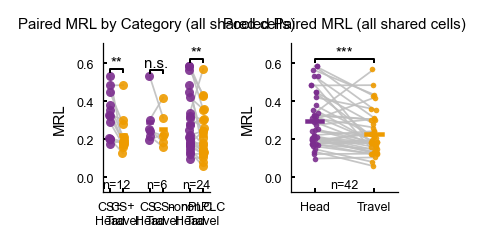

Saved figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_full/comparison_head_vs_travel_all_spike/head_vs_travel_all_spike_allcells_paired_real_mrl.svg


In [8]:
def p_text(test_name, p_value, sig):
    if not np.isfinite(p_value):
        return 'n/a'
    if test_name == 'all_equal':
        return 'n.s.'
    return str(sig)

def add_bracket(ax, x1, x2, y, text, h=0.02, lw=0.8):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='k', lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2.0, y + h, text, ha='center', va='bottom', fontsize=6)

rng = np.random.default_rng(42)

all_vals = np.concatenate([
    pd.to_numeric(paired_df['head_mrl'], errors='coerce').to_numpy(dtype=float),
    pd.to_numeric(paired_df['travel_mrl'], errors='coerce').to_numpy(dtype=float),
]) if len(paired_df) else np.array([0.0], dtype=float)
all_vals = all_vals[np.isfinite(all_vals)]
y_max = float(np.nanmax(all_vals)) if all_vals.size else 0.3
y_top = max(0.3, y_max + 0.12)
y_bottom = -0.08

style = {
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'font.size': 6.0,
    'axes.labelsize': 6.0,
    'axes.titlesize': 6.0,
    'xtick.labelsize': 5.0,
    'ytick.labelsize': 5.0,
    'xtick.major.size': 1.75,
    'ytick.major.size': 1.75,
    'xtick.minor.size': 1.0,
    'ytick.minor.size': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 5.0,
    'axes.linewidth': 0.5,
}

with plt.rc_context(style):
    fig, axes = plt.subplots(1, 2, figsize=(2, 1.25), dpi=180, constrained_layout=True)

    # Panel 1: category-wise paired MRL
    ax = axes[0]
    xticks = []
    xlabels = []
    for i, category in enumerate(CATEGORY_ORDER):
        sub = paired_df.loc[paired_df['category'] == category].copy()
        head_vals = pd.to_numeric(sub['head_mrl'], errors='coerce').to_numpy(dtype=float)
        travel_vals = pd.to_numeric(sub['travel_mrl'], errors='coerce').to_numpy(dtype=float)
        x_head = float(i * 3.0)
        x_travel = float(i * 3.0 + 1.0)
        x_center = 0.5 * (x_head + x_travel)

        if head_vals.size:
            jit_h = rng.uniform(-0.05, 0.05, head_vals.size)
            jit_t = rng.uniform(-0.05, 0.05, travel_vals.size)
            for h_val, t_val in zip(head_vals, travel_vals):
                ax.plot([x_head, x_travel], [h_val, t_val], color='0.75', lw=0.7, alpha=0.9, zorder=1)
            ax.scatter(np.full(head_vals.size, x_head) + jit_h, head_vals, s=13, color=HEAD_COLOR, alpha=0.9, linewidths=0, zorder=2)
            ax.scatter(np.full(travel_vals.size, x_travel) + jit_t, travel_vals, s=13, color=TRAVEL_COLOR, alpha=0.9, linewidths=0, zorder=2)
            ax.plot([x_head - 0.13, x_head + 0.13], [float(np.nanmean(head_vals)), float(np.nanmean(head_vals))], color=HEAD_COLOR, lw=1.8, zorder=3)
            ax.plot([x_travel - 0.13, x_travel + 0.13], [float(np.nanmean(travel_vals)), float(np.nanmean(travel_vals))], color=TRAVEL_COLOR, lw=1.8, zorder=3)

        row = stats_df.loc[stats_df['group'] == category].iloc[0]
        local_max = 0.02
        if head_vals.size:
            local_max = max(local_max, float(np.nanmax(head_vals)))
        if travel_vals.size:
            local_max = max(local_max, float(np.nanmax(travel_vals)))
        add_bracket(ax, x_head, x_travel, local_max + 0.02, p_text(str(row['test']), float(row['p_value']) if np.isfinite(row['p_value']) else np.nan, str(row['sig'])), h=0.015)
        ax.text(x_center, y_bottom + 0.01, f'n={int(row["n_pairs"])}', ha='center', va='bottom', fontsize=5)

        xticks.extend([x_head, x_travel])
        xlabels.extend([f'{CATEGORY_LABEL[category]}\nHead', f'{CATEGORY_LABEL[category]}\nTravel'])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(y_bottom, y_top)
    ax.set_ylabel('MRL')
    ax.set_title('Paired MRL by Category (all shared cells)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel 2: pooled paired MRL
    ax = axes[1]
    pooled_head = pd.to_numeric(paired_df['head_mrl'], errors='coerce').to_numpy(dtype=float)
    pooled_travel = pd.to_numeric(paired_df['travel_mrl'], errors='coerce').to_numpy(dtype=float)
    x_head = 0.0
    x_travel = 1.0
    if pooled_head.size:
        jit_h = rng.uniform(-0.06, 0.06, pooled_head.size)
        jit_t = rng.uniform(-0.06, 0.06, pooled_travel.size)
        for h_val, t_val in zip(pooled_head, pooled_travel):
            ax.plot([x_head, x_travel], [h_val, t_val], color='0.75', lw=0.7, alpha=0.9, zorder=1)
        ax.scatter(np.full(pooled_head.size, x_head) + jit_h, pooled_head, s=5, color=HEAD_COLOR, alpha=0.9, linewidths=0, zorder=2)
        ax.scatter(np.full(pooled_travel.size, x_travel) + jit_t, pooled_travel, s=5, color=TRAVEL_COLOR, alpha=0.9, linewidths=0, zorder=2)
        ax.plot([x_head - 0.13, x_head + 0.13], [float(np.nanmean(pooled_head)), float(np.nanmean(pooled_head))], color=HEAD_COLOR, lw=1.8, zorder=3)
        ax.plot([x_travel - 0.13, x_travel + 0.13], [float(np.nanmean(pooled_travel)), float(np.nanmean(pooled_travel))], color=TRAVEL_COLOR, lw=1.8, zorder=3)

    pooled_row = stats_df.loc[stats_df['group'] == 'pooled'].iloc[0]
    pooled_max = 0.02
    if pooled_head.size:
        pooled_max = max(pooled_max, float(np.nanmax(pooled_head)))
    if pooled_travel.size:
        pooled_max = max(pooled_max, float(np.nanmax(pooled_travel)))
    add_bracket(ax, x_head, x_travel, pooled_max + 0.02, p_text(str(pooled_row['test']), float(pooled_row['p_value']) if np.isfinite(pooled_row['p_value']) else np.nan, str(pooled_row['sig'])), h=0.015)
    ax.text(0.5, y_bottom + 0.01, f'n={int(pooled_row["n_pairs"])}', ha='center', va='bottom', fontsize=5)

    ax.set_xticks([x_head, x_travel])
    ax.set_xticklabels(['Head', 'Travel'])
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(y_bottom, y_top)
    ax.set_ylabel('MRL')
    ax.set_title('Pooled Paired MRL (all shared cells)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.savefig(OUT_FIG, bbox_inches='tight')
    plt.show()

print('Saved figure:', OUT_FIG)
